Dataset shape: (891, 12)
Training samples: 571
Testing samples: 143
Accuracy: 0.7832167832167832


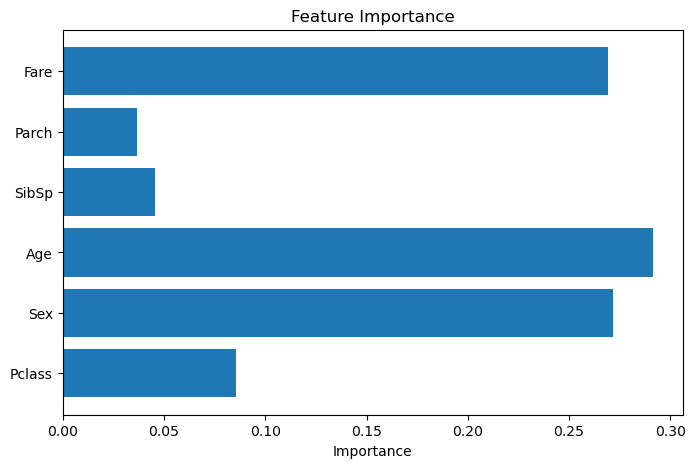

SURVIVED ✅
DIED ❌


In [1]:
# ================================================
# Titanic Survival Predictor
# Author: Your Name
# Description: Predict survival using ML models
# ================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ---- 1. Load Data ----
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Dataset shape:", df.shape)

# ---- 2. Clean Data ----
df = df.dropna(subset=["Age"])
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# ---- 3. Select Features ----
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = df[features]
y = df["Survived"]

# ---- 4. Split Data ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ---- 5. Train Model ----
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ---- 6. Evaluate Model ----
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# ---- 7. Feature Importance ----
plt.figure(figsize=(8, 5))
plt.barh(features, model.feature_importances_)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

# ---- 8. Predict New Passenger ----
def predict_survival(pclass, sex, age, sibsp, parch, fare):
    passenger = pd.DataFrame([[pclass, sex, age, sibsp, parch, fare]], columns=features)
    result = model.predict(passenger)
    return "SURVIVED ✅" if result[0] == 1 else "DIED ❌"

# Test it
print(predict_survival(pclass=1, sex=1, age=25, sibsp=0, parch=0, fare=72))
print(predict_survival(pclass=3, sex=0, age=25, sibsp=0, parch=0, fare=8))